In [14]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [15]:
df = pd.read_csv(r"D:\Downloads\Housing.csv")

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [17]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [19]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [20]:
df.duplicated().sum()

0

In [21]:
pd.get_dummies(df).sum()

price                              2597867440
area                                  2807045
bedrooms                                 1616
bathrooms                                 701
stories                                   984
parking                                   378
mainroad_no                                77
mainroad_yes                              468
guestroom_no                              448
guestroom_yes                              97
basement_no                               354
basement_yes                              191
hotwaterheating_no                        520
hotwaterheating_yes                        25
airconditioning_no                        373
airconditioning_yes                       172
prefarea_no                               417
prefarea_yes                              128
furnishingstatus_furnished                140
furnishingstatus_semi-furnished           227
furnishingstatus_unfurnished              178
dtype: int64

In [22]:
def plot_histogram(df,column_name):
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name],kde=True)
    plt.title(f"Distribution of {column_name}")

    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    plt.axvline(col_mean,color='red',linestyle='--',label='mean')
    plt.axvline(col_median, color="green", linestyle="-", label="Median")
    plt.legend()
    plt.show()

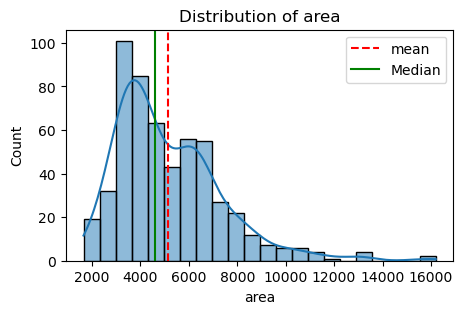

In [23]:
plot_histogram(df, "area")

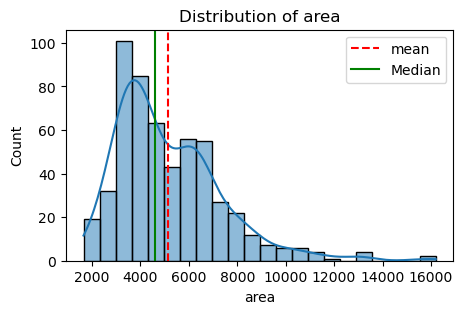

In [25]:
plot_histogram(df, "area")

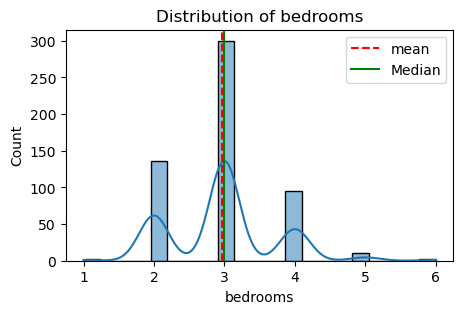

In [24]:
plot_histogram(df, "bedrooms")

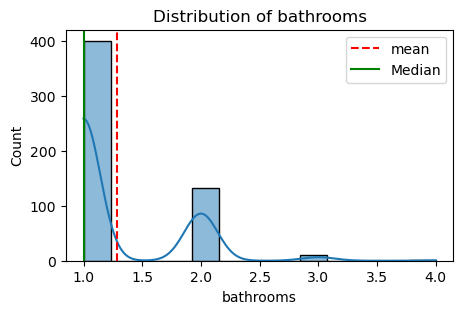

In [26]:
plot_histogram(df, "bathrooms")

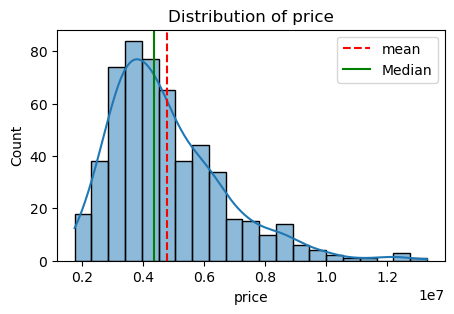

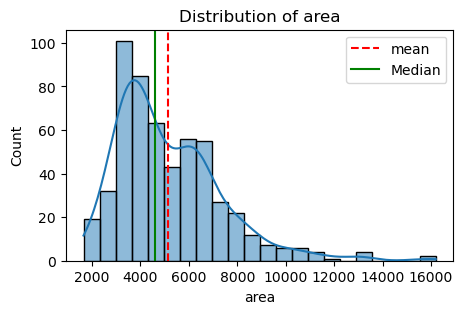

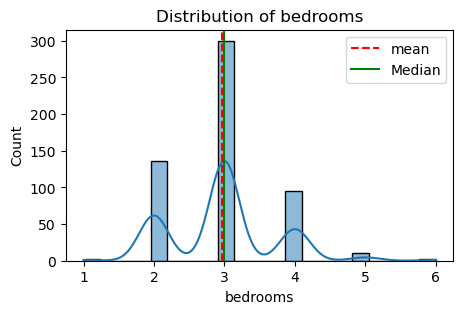

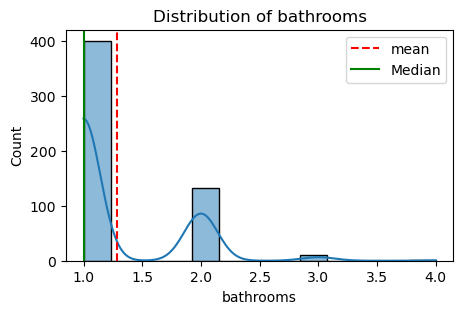

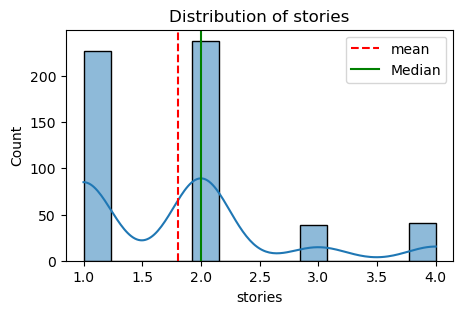

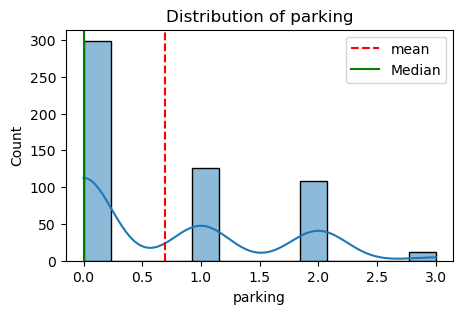

In [28]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        plot_histogram(df, col)
    elif df[col].dtype == 'object':
        def plot_categorical(df, column_name):
            plt.figure(figsize=(5,3))
            sns.countplot(data=df, x=column_name)
            plt.title(f"Count of {column_name}")
            plt.xticks(rotation=45)
            plt.show()


In [29]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show

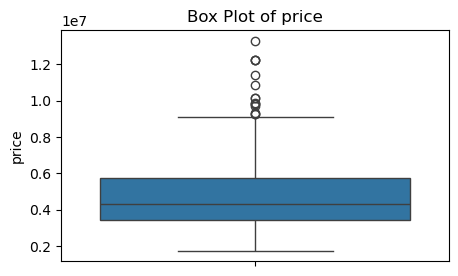

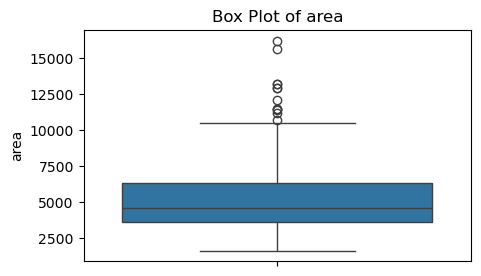

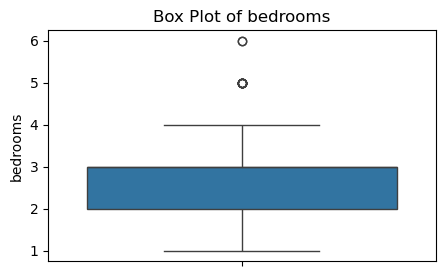

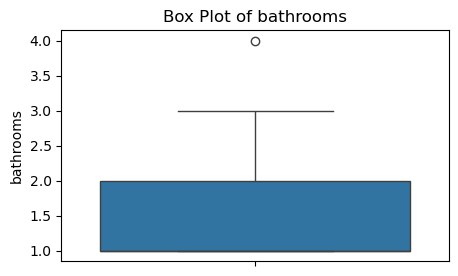

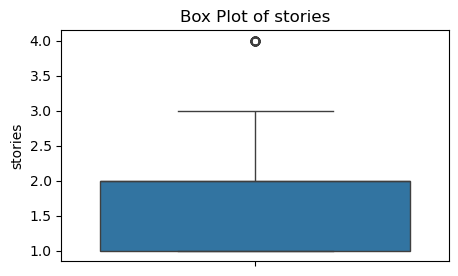

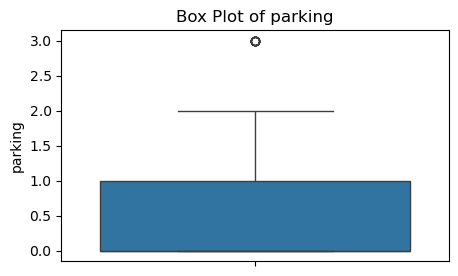

In [30]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        plot_boxplot(df, col)
    elif df[col].dtype == 'object':
        def plot_categorical(df, column_name):
            plt.figure(figsize=(5,3))
            sns.boxplot(data=df, x=column_name)
            plt.title(f"Count of {column_name}")
            plt.xticks(rotation=45)
            plt.show()


1.data set has object values convert them to int 
2. most of the data is right skewd make it normal 
3. there are so many outliers 